In [1]:
import matplotlib.pyplot as plt
import numpy as np
import openml
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier


import warnings
warnings.filterwarnings("ignore")

# Set display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [2]:

dataset = openml.datasets.get_dataset(46858)

X, y, categorical_indicator, attribute_names = dataset.get_data(
    dataset_format="dataframe",
    target="isFraud"
)


## Removing the columns from 50% of null values

In [3]:
df = X.copy()
df["isFraud"] = y
df["isFraud"]= pd.to_numeric(df.isFraud.astype(str), errors= "coerce")

In [4]:
df.shape

(590540, 456)

In [5]:
null_percentages = pd.DataFrame((df.isnull().sum()/len(df))*100,columns = ['percentage'])
remove_features = null_percentages[null_percentages['percentage']>=50].index

#Columns count to be removed
print("Total count of columns to be removed:",len(remove_features))

# Total number of fields
print("Total count of columns in transaction data:",len(null_percentages))

Total count of columns to be removed: 237
Total count of columns in transaction data: 456


In [6]:
# Removing the columns >=50% null values
df.drop(remove_features,axis=1,inplace=True)

In [7]:
# Replace all columns with "-" to "_"
df.rename(columns=lambda x: x.replace('-', '_'), inplace=True)



In [8]:
df.shape

(590540, 219)

## Handling missing values

In [9]:
(df.isna().sum()/len(df)).sort_values(ascending=False)*100


M4                47.658753
D2                47.549192
V3                47.293494
D11               47.293494
V1                47.293494
V2                47.293494
V4                47.293494
V5                47.293494
V6                47.293494
V7                47.293494
V8                47.293494
V9                47.293494
V10               47.293494
V11               47.293494
M3                45.907136
M2                45.907136
M1                45.907136
D3                44.514851
M6                28.678836
V50               28.612626
V42               28.612626
V41               28.612626
V40               28.612626
V39               28.612626
V44               28.612626
V49               28.612626
V37               28.612626
V36               28.612626
V35               28.612626
V45               28.612626
V46               28.612626
V47               28.612626
V48               28.612626
V52               28.612626
V51               28.612626
V38               28

In [10]:
# Separating continuous and random column names

categories_features = [i for i in df.columns if df[i].dtype =="object" ]
continuous_features = [elem for elem in df.columns if elem not in categories_features]

In [11]:
# Categorical
for col in categories_features:
    df[col] = df[col].fillna("Missing")

# Continuous
for col in continuous_features:
    df[col] = df[col].fillna(df[col].median())

In [12]:
df.isna().sum()

TransactionDT     0
TransactionAmt    0
ProductCD         0
card1             0
card2             0
card3             0
card4             0
card5             0
card6             0
addr1             0
addr2             0
P_emaildomain     0
C1                0
C2                0
C3                0
C4                0
C5                0
C6                0
C7                0
C8                0
C9                0
C10               0
C11               0
C12               0
C13               0
C14               0
D1                0
D2                0
D3                0
D4                0
D10               0
D11               0
D15               0
M1                0
M2                0
M3                0
M4                0
M6                0
V1                0
V2                0
V3                0
V4                0
V5                0
V6                0
V7                0
V8                0
V9                0
V10               0
V11               0
V12               0


## Data Split

In [13]:
df = df.sort_values("TransactionDT").reset_index(drop=True)

X_raw = df.drop(columns=["isFraud"])
y_raw = df["isFraud"].astype(int)


train_end = int(len(df) * 0.60)
validation_end = int(len(df) * 0.80)

X_train_raw = X_raw.iloc[:train_end]
X_validation_raw = X_raw.iloc[train_end:validation_end]
X_test_raw = X_raw.iloc[validation_end:]

y_train = y_raw.iloc[:train_end].to_numpy()
y_validation = y_raw.iloc[train_end:validation_end].to_numpy()
y_test = y_raw.iloc[validation_end:].to_numpy()

print("Train:", X_train_raw.shape, "Validation:", X_validation_raw.shape, "Test:", X_test_raw.shape)

Train: (354324, 218) Validation: (118108, 218) Test: (118108, 218)


In [14]:
X_train_raw.select_dtypes(exclude="number").columns.tolist()

['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M6']

## Converting categorical data into numbers 

In [15]:


X_train = pd.get_dummies(
    X_train_raw,
    columns=categories_features,
    dummy_na=True,
    dtype=int,
)

X_validation = pd.get_dummies(
    X_validation_raw,
    columns=categories_features,
    dummy_na=True,
).reindex(columns=X_train.columns, fill_value=0).astype(int)

X_test = pd.get_dummies(
    X_test_raw,
    columns=categories_features,
    dummy_na=True,
).reindex(columns=X_train.columns, fill_value=0).astype(int)

print("Encoded features:", X_train.shape[1])

Encoded features: 309


In [16]:
split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "transactions": [len(y_train), len(y_validation), len(y_test)],
    "fraud_rate": [y_train.mean(), y_validation.mean(), y_test.mean()],
    "fraud_count": [y_train.sum(), y_validation.sum(), y_test.sum()],
})

split_summary.style.format({"fraud_rate": "{:.2%}"})

,split,transactions,fraud_rate,fraud_count
0,train,354324,3.38%,11988
1,validation,118108,3.90%,4611
2,test,118108,3.44%,4064


In [17]:
print("Train fraud rate:", y_train.mean())
print("Validation fraud rate:", y_validation.mean())
print("Test fraud rate:", y_test.mean())
print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

Train fraud rate: 0.03383344057980831
Validation fraud rate: 0.03904053916754157
Test fraud rate: 0.034409184813899145
X_train: (354324, 309)
X_validation: (118108, 309)
X_test: (118108, 309)


In [18]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 28.556556556556558


In [19]:
def evaluate_thresholds(
    X_train,
    y_train,
    X_validation,
    y_validation,
    model,
    model_name,
    thresholds=np.arange(0.05, 1.00, 0.05),
):
    """Fit on train data and choose an operating threshold on validation data."""
    model.fit(X_train, y_train)
    validation_probabilities = model.predict_proba(X_validation)[:, 1]
    results = []

    for threshold in thresholds:
        predicted = (validation_probabilities >= threshold).astype(int)
        results.append({
            "model": model_name,
            "threshold": round(float(threshold), 2),
            "precision": precision_score(y_validation, predicted, zero_division=0),
            "recall": recall_score(y_validation, predicted, zero_division=0),
            "f1": f1_score(y_validation, predicted, zero_division=0),
            "fraud_flagged": int(predicted.sum()),
        })

    validation_results = pd.DataFrame(results)
    best_row = validation_results.loc[validation_results["f1"].idxmax()]
    return model, validation_results, best_row

In [20]:
# Compare classifiers
clf1 = LogisticRegression(
    class_weight={0: 1, 1: 15},
    random_state=5,
    solver="liblinear",
    max_iter=1000,
)

clf2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

clf3 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
)

In [21]:
models = [
    (clf1, "Logistic Regression"),
    (clf2, "Random Forest"),
    (clf3, "XGBoost"),
]

fitted_models = {}
validation_results = []
best_validation_rows = []

for model, model_name in models:
    fitted_model, result, best_row = evaluate_thresholds(
        X_train,
        y_train,
        X_validation,
        y_validation,
        model,
        model_name,
    )
    fitted_models[model_name] = fitted_model
    validation_results.append(result)
    best_validation_rows.append(best_row)

comparison = pd.concat(validation_results, ignore_index=True)
best_validation = pd.DataFrame(best_validation_rows).reset_index(drop=True)
best_validation.sort_values("f1", ascending=False)

,model,threshold,precision,recall,f1,fraud_flagged
2,XGBoost,0.85,0.651429,0.445023,0.528798,3150
1,Random Forest,0.70,0.434352,0.465626,0.449445,4943
0,Logistic Regression,0.60,0.196528,0.407504,0.265171,9561


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\anhch\\OneDrive\\Desktop\\cv\\Fraud-Detection\\.charts\\Eval.png'

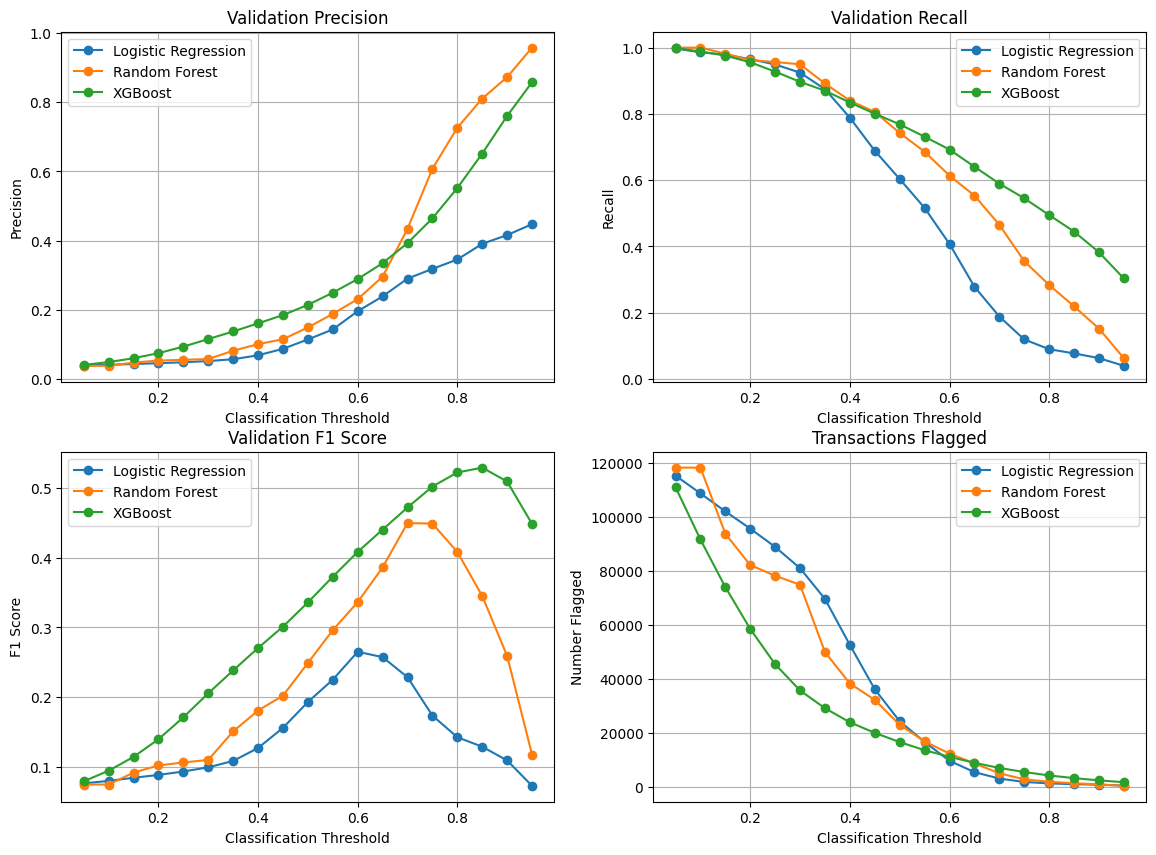

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = [
    ("precision", "Validation Precision", "Precision"),
    ("recall", "Validation Recall", "Recall"),
    ("f1", "Validation F1 Score", "F1 Score"),
    ("fraud_flagged", "Transactions Flagged", "Number Flagged"),
]

for axis, (metric, title, ylabel) in zip(axes.ravel(), metrics):
    for model_name, group in comparison.groupby("model"):
        axis.plot(
            group["threshold"],
            group[metric],
            marker="o",
            label=model_name,
        )

    axis.set_title(title)
    axis.set_xlabel("Classification Threshold")
    axis.set_ylabel(ylabel)
    axis.grid(True)
    axis.legend()
plt.savefig(
    "./charts/Eval.png",
    dpi=300,
    bbox_inches="tight",
)

plt.tight_layout()
plt.show()

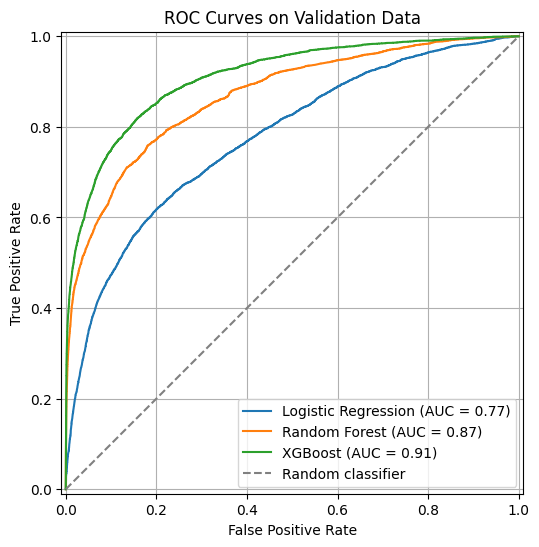

In [28]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

for model_name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_validation,
        y_validation,
        name=model_name,
        ax=plt.gca(),
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier",
)
plt.savefig(
    "roc_curves.png",
    dpi=300,
    bbox_inches="tight",
)



plt.title("ROC Curves on Validation Data")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
final_results = []

for model_name, model in fitted_models.items():
    threshold = float(
        best_validation.loc[
            best_validation["model"] == model_name,
            "threshold",
        ].iloc[0]
    )
    test_probabilities = model.predict_proba(X_test)[:, 1]
    test_predictions = (test_probabilities >= threshold).astype(int)

    final_results.append({
        "model": model_name,
        "threshold_from_validation": threshold,
        "roc_auc": roc_auc_score(y_test, test_probabilities),
        "pr_auc": average_precision_score(y_test, test_probabilities),
        "precision": precision_score(y_test, test_predictions, zero_division=0),
        "recall": recall_score(y_test, test_predictions, zero_division=0),
        "f1": f1_score(y_test, test_predictions, zero_division=0),
        "fraud_flagged": int(test_predictions.sum()),
    })

final_results = (
    pd.DataFrame(final_results)
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

final_results.style.format({
    "threshold_from_validation": "{:.2f}",
    "roc_auc": "{:.3f}",
    "pr_auc": "{:.3f}",
    "precision": "{:.2%}",
    "recall": "{:.2%}",
    "f1": "{:.3f}",
})
final_results.sort_values("f1", ascending=False).iloc[0]

model                         XGBoost
threshold_from_validation        0.85
roc_auc                      0.881594
pr_auc                       0.446031
precision                    0.563248
recall                       0.382382
f1                           0.455518
fraud_flagged                    2759
Name: 0, dtype: object

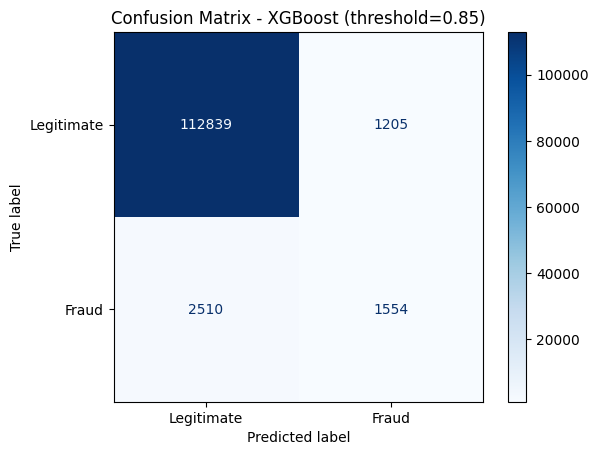

True negatives: 112839
False positives: 1205
False negatives: 2510
True positives: 1554


In [24]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Choose the model using validation F1, not test F1
best_model_name = (
    best_validation
    .sort_values("f1", ascending=False)
    .iloc[0]["model"]
)

best_model = fitted_models[best_model_name]

best_threshold = float(
    best_validation.loc[
        best_validation["model"] == best_model_name,
        "threshold"
    ].iloc[0]
)

# Predict on the untouched test set
test_probabilities = best_model.predict_proba(X_test)[:, 1]
test_predictions = (
    test_probabilities >= best_threshold
).astype(int)

# Create confusion matrix
cm = confusion_matrix(y_test, test_predictions)

display_labels = ["Legitimate", "Fraud"]

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels
)

display.plot(cmap="Blues", values_format="d")
plt.title(
    f"Confusion Matrix - {best_model_name} "
    f"(threshold={best_threshold:.2f})"
)
plt.show()

tn, fp, fn, tp = cm.ravel()

print("True negatives:", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives:", tp)